# Analyse exploratoire : distributions et évolution du marché

Objectif : regarder comment se distribuent les variables clés (prix, genres,
langues) et comment le marché Steam a évolué dans le temps. C'est la première
moitié de l'analyse exploratoire : on reste sur des analyses simples, variable
par variable.

Ce notebook part du fichier produit par `02_cleaning.ipynb`.

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/games_clean.csv', parse_dates=['Release date'])
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dimensions : 125854 lignes, 38 colonnes


## Rappel rapide

On regarde la période couverte par le dataset avant toute chose, ça permet
de cadrer les graphiques qui suivent.

In [3]:
print(f"Période couverte : {int(df['release_year'].min())} à {int(df['release_year'].max())}")
print(f"Nombre de jeux par tranche de prix (aperçu) :")
df['Price'].describe()

Période couverte : 1997 à 2026
Nombre de jeux par tranche de prix (aperçu) :


count    125854.000000
mean          4.811213
std          12.489371
min           0.000000
25%           0.590000
50%           2.390000
75%           5.547500
max         999.980000
Name: Price, dtype: float64

## Distribution du prix

Le prix est très asymétrique (énormément de jeux pas chers, quelques très
chers) donc on l'affiche en échelle logarithmique, et uniquement sur les jeux
payants (le détail F2P vs payant arrive juste après).

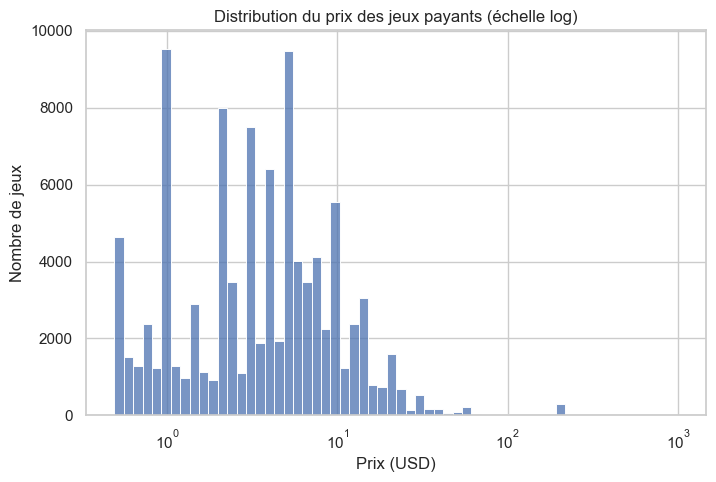

count    99194.000000
mean         6.104304
std         13.784581
min          0.490000
25%          1.490000
50%          3.590000
75%          6.990000
max        999.980000
Name: Price, dtype: float64


In [4]:
jeux_payants = df.loc[df['Price'] > 0, 'Price']

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(jeux_payants, bins=60, log_scale=True, ax=ax)
ax.set_title('Distribution du prix des jeux payants (échelle log)')
ax.set_xlabel('Prix (USD)')
ax.set_ylabel("Nombre de jeux")
plt.show()

print(jeux_payants.describe())

## Free-to-play vs payant

On compare simplement la proportion de jeux gratuits (`Price == 0`) par
rapport aux jeux payants.

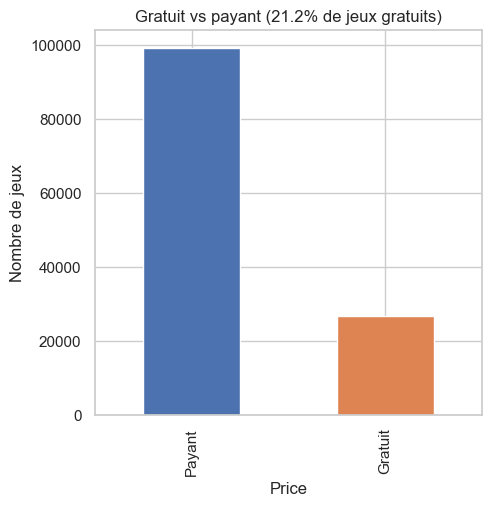

In [5]:
repartition_prix = df['Price'].apply(lambda p: 'Gratuit' if p == 0 else 'Payant').value_counts()
pct_gratuit = (df['Price'] == 0).mean() * 100

fig, ax = plt.subplots(figsize=(5, 5))
repartition_prix.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title(f"Gratuit vs payant ({pct_gratuit:.1f}% de jeux gratuits)")
ax.set_ylabel('Nombre de jeux')
plt.show()

## Genres dominants

On utilise `main_genre` (le premier genre listé pour chaque jeu, créé au
Jour 2). "Unknown" correspond aux jeux sans genre renseigné dans la source,
on le garde affiché pour rester honnête sur la qualité des données mais on
ne s'y attarde pas dans l'analyse.

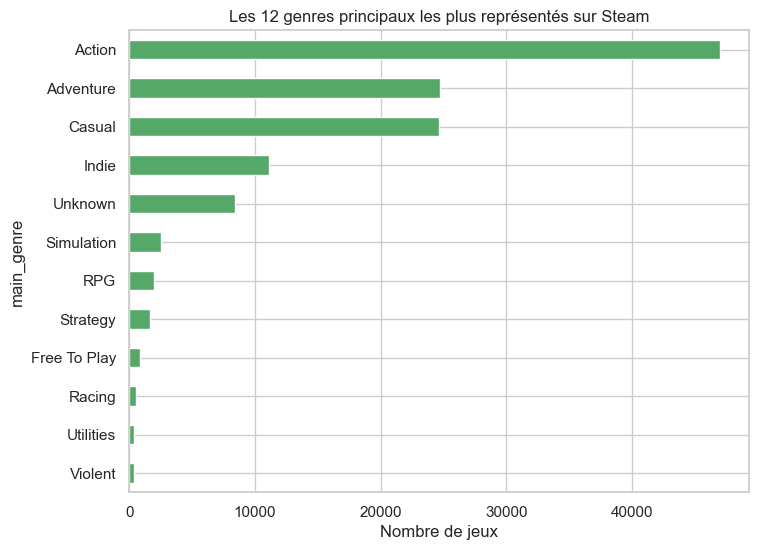

main_genre
Action          47012
Adventure       24704
Casual          24684
Indie           11108
Unknown          8422
Simulation       2521
RPG              1980
Strategy         1627
Free To Play      879
Racing            557
Utilities         357
Violent           350
Name: count, dtype: int64


In [6]:
top_genres = df['main_genre'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(8, 6))
top_genres.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title('Les 12 genres principaux les plus représentés sur Steam')
ax.set_xlabel('Nombre de jeux')
plt.show()

print(top_genres)

## Langues supportées

`Supported languages` est stockée comme une liste Python écrite en texte
(ex : `"['English', 'French']"`), donc on la parse avec `ast.literal_eval`
pour pouvoir compter le nombre de langues par jeu et identifier les langues
les plus fréquentes sur l'ensemble du catalogue.

In [7]:
def parser_langues(valeur):
    """Transforme la chaîne \"['English', 'French']\" en vraie liste Python."""
    if pd.isna(valeur):
        return []
    try:
        parsed = ast.literal_eval(str(valeur))
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return []

langues_par_jeu = df['Supported languages'].apply(parser_langues)
df['nb_langues'] = langues_par_jeu.apply(len)

print(df['nb_langues'].describe())

count    125854.000000
mean          3.606751
std           5.453360
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          97.000000
Name: nb_langues, dtype: float64


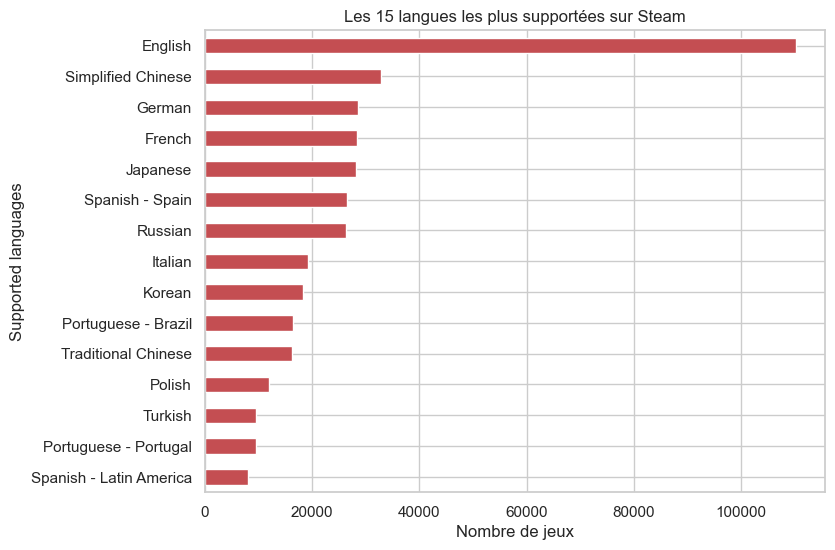

In [8]:
toutes_les_langues = langues_par_jeu.explode().dropna()
top_langues = toutes_les_langues.value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_langues.sort_values().plot(kind='barh', ax=ax, color='#C44E52')
ax.set_title('Les 15 langues les plus supportées sur Steam')
ax.set_xlabel('Nombre de jeux')
plt.show()

## Évolution du nombre de sorties par année

On filtre à partir de 2004 (Steam a ouvert en 2003, les quelques jeux datés
avant ne reflètent pas vraiment le catalogue Steam). La dernière année du
dataset est probablement incomplète puisqu'elle correspond à l'année en
cours au moment de la collecte des données : à interpréter avec prudence,
pas comme une vraie baisse du marché.

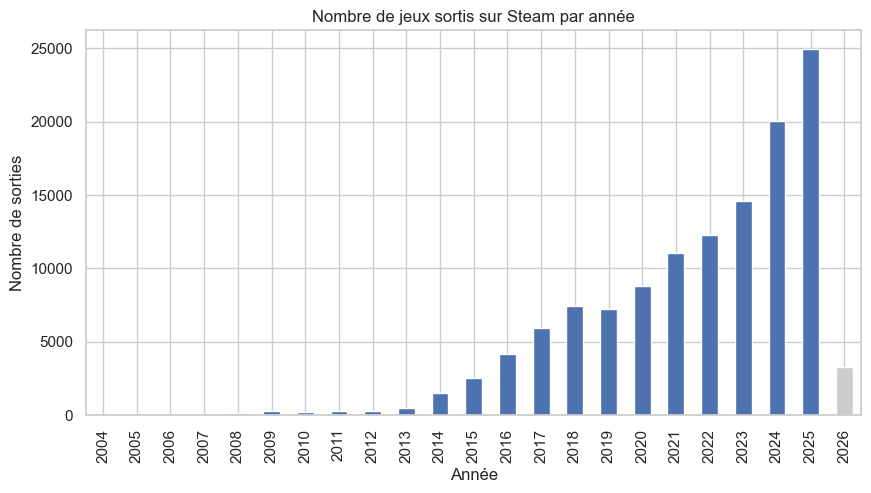

release_year
2019     7243
2020     8804
2021    11067
2022    12288
2023    14598
2024    20033
2025    24973
2026     3316
Name: count, dtype: int64


In [9]:
evolution = df[df['release_year'] >= 2004]['release_year'].value_counts().sort_index()
derniere_annee = int(evolution.index.max())

fig, ax = plt.subplots(figsize=(10, 5))
couleurs = ['#4C72B0' if annee != derniere_annee else '#CCCCCC' for annee in evolution.index]
evolution.plot(kind='bar', ax=ax, color=couleurs)
ax.set_title('Nombre de jeux sortis sur Steam par année')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de sorties')

plt.show()

print(evolution.tail(8))

## Synthèse

Quelques constats à garder pour la suite (et pour le storytelling de
l'application) :

- Le prix est extrêmement concentré sur les jeux peu chers, avec une longue
  traîne de jeux premium beaucoup plus rares
- Une part significative du catalogue est gratuite (F2P)
- Quelques genres (Action, Adventure, Casual, Indie) dominent largement le
  catalogue
- La grande majorité des jeux ne sont disponibles qu'en anglais ; un petit
  nombre de jeux "AAA" tirent vers le haut la moyenne de langues supportées
- Le nombre de sorties annuelles a explosé depuis le milieu des années 2010
  (démocratisation de la distribution sur Steam), ce qui est probablement le
  fil rouge le plus fort pour raconter l'histoire du marché